# TraceWin distribution viewer

This notebook reads TraceWin binary `.dst` distributions and plots the transverse phase spaces.

It uses fixed paths: one input distribution, all intermediate `.dst` files inside `calc/`, and the final `part_dtl1.dst`.
Run all cells after each TraceWin/PARTRAN run so the files are reloaded from disk.

In [25]:
# Basic imports.
# pathlib handles file paths cleanly; numpy/pandas/matplotlib are used for data and plots.
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the beam_optimization package importable when this notebook is run directly.
PROJECT_PARENT = Path('/mnt/shared_volume/FEDERICO_TESI')
if str(PROJECT_PARENT) not in sys.path:
    sys.path.insert(0, str(PROJECT_PARENT))

from beam_optimization.env.tracewin_env.tracewin.visualization import (
    find_final_tracewin_dst_path,
    plot_tracewin_distribution,
    tracewin_distribution_from_dst,
)

# Fixed TraceWin run paths.
# CALC_DIR is the folder refreshed by TraceWin/PARTRAN after a run.
#CALC_DIR = Path('/mnt/shared_volume/FEDERICO_TESI/DANIELE/TRACEWIN_WORKSPACE_test/TRACEWIN_WORKSPACE_0/calc')
#DST_INPUT = Path('/mnt/shared_volume/FEDERICO_TESI/DANIELE/TRACEWIN_WORKSPACE_test/TRACEWIN_WORKSPACE_0/16O5.dst')
CALC_DIR = Path('/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc')
DST_INPUT = Path('/mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/16O5.dst')
DST_OUTPUT = find_final_tracewin_dst_path(CALC_DIR)
PARTRAN_FILE = CALC_DIR / 'partran1.out'

# Print the exact files used, so it is obvious which TraceWin run is being plotted.
print(f'CALC_DIR    = {CALC_DIR}')
print(f'DST_INPUT   = {DST_INPUT}')
print(f'DST_OUTPUT  = {DST_OUTPUT}')
print(f'PARTRAN_OUT = {PARTRAN_FILE}')


CALC_DIR    = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc
DST_INPUT   = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/16O5.dst
DST_OUTPUT  = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc/3.dst
PARTRAN_OUT = /mnt/shared_volume/FEDERICO_TESI/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc/partran1.out


In [26]:
def natural_key(path):
    # Sort filenames naturally: 2.dst comes before 11.dst.
    parts = re.split(r'(\d+)', Path(path).name)
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def read_npart_simulated(partran_file):
    # Read the number of simulated macro-particles from the partran1.out header.
    with open(partran_file) as f:
        f.readline()
        values = f.readline().split()
    return int(values[-1])


NPART_SIMULATED = read_npart_simulated(PARTRAN_FILE)

# Intermediate distributions are every .dst file written in calc/ by PLOT_DST,
# excluding TraceWin's standard input/output names and the selected final output.
excluded_names = {'part_rfq.dst', 'part_dtl1.dst'}
intermediate_files = [
    path for path in sorted(CALC_DIR.glob('*.dst'), key=natural_key)
    if path.name not in excluded_names and path != DST_OUTPUT
]

# Plot order: reservoir input, PLOT_DST snapshots, final output if available.
distribution_files = [DST_INPUT, *intermediate_files]
if DST_OUTPUT is not None:
    distribution_files.append(DST_OUTPUT)

missing_files = [path for path in distribution_files if not path.exists()]
if missing_files:
    print('Skipped missing distribution files:')
    for path in missing_files:
        print(f'  {path}')
distribution_files = [path for path in distribution_files if path.exists()]

distributions = []
for path in distribution_files:
    role = 'input' if path == DST_INPUT else 'output' if path == DST_OUTPUT else 'intermediate'

    # Figure title: explicit names for the endpoints; raw filename for intermediate PLOT_DST files.
    display_title = {
        'input': 'Input distribution',
        'output': 'Output distribution',
        'intermediate': path.name,
    }[role]

    distribution = tracewin_distribution_from_dst(path)
    distributions.append({
        'title': display_title,
        'filename': path.name,
        'role': role,
        'path': path,
        'distribution': distribution,
        'n_particles': len(distribution['x']),
    })

print(f'NPART_SIMULATED = {NPART_SIMULATED:,}')
print('Loaded distributions:')
for item in distributions:
    modified = pd.Timestamp(item['path'].stat().st_mtime, unit='s')
    print(f"  {item['title']:<20} {item['filename']:<14} {item['role']:<12} {item['n_particles']:>10,} particles   modified: {modified}")


NPART_SIMULATED = 10,000
Loaded distributions:
  Input distribution   16O5.dst       input         2,280,258 particles   modified: 2026-06-22 12:53:38.464639902
  1.dst                1.dst          intermediate     10,000 particles   modified: 2026-06-23 09:23:34.747010946
  2.dst                2.dst          intermediate     10,000 particles   modified: 2026-06-23 09:23:34.964011669
  Output distribution  3.dst          output           10,000 particles   modified: 2026-06-23 09:23:35.089012384


In [27]:
# Distribution plotting is centralized in:
# beam_optimization.env.tracewin_env.tracewin.visualization.plot_tracewin_distribution
# The same function is used by TraceWinEnv.render_final_beam_distribution().


In [28]:
# partran1.out contains element-by-element beam statistics.
# We use it here for z positions and for the aperture column in the x-y plots.
df = pd.read_csv(PARTRAN_FILE, sep=r'\s+', header=0, skiprows=9)
z = df['z(m)']

print(f'Loaded {len(df)} rows from {PARTRAN_FILE.name}')

Loaded 182 rows from partran1.out


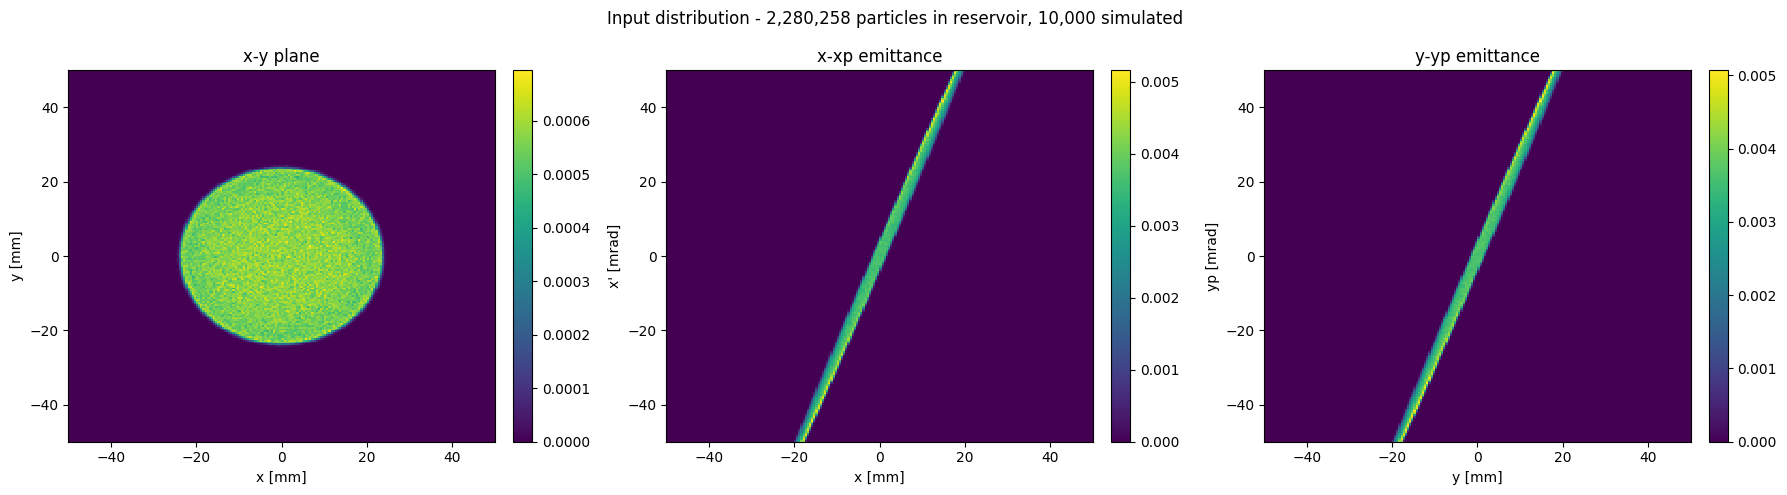

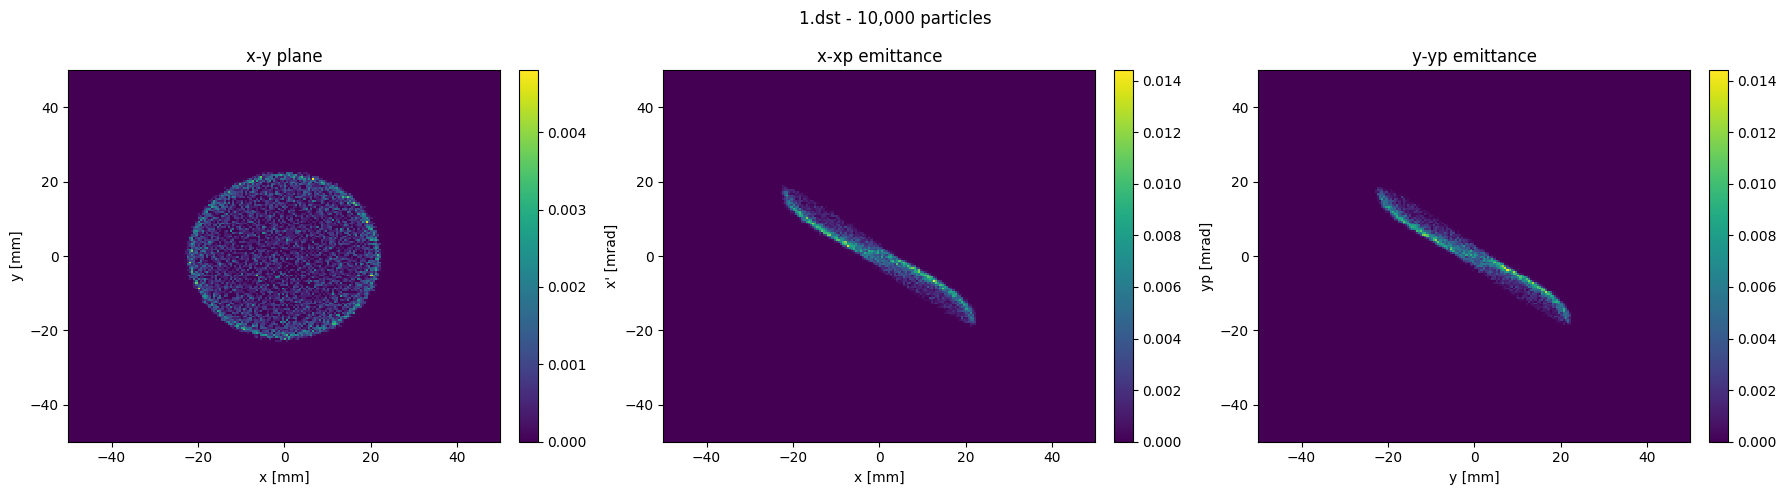

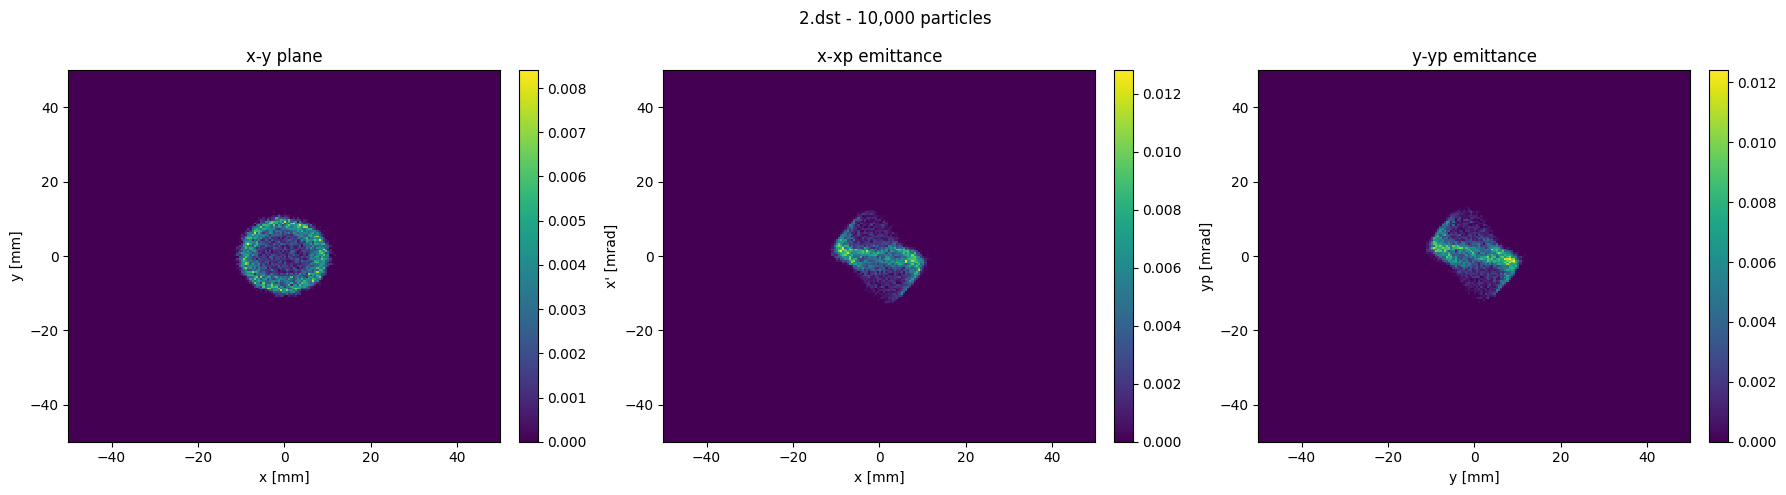

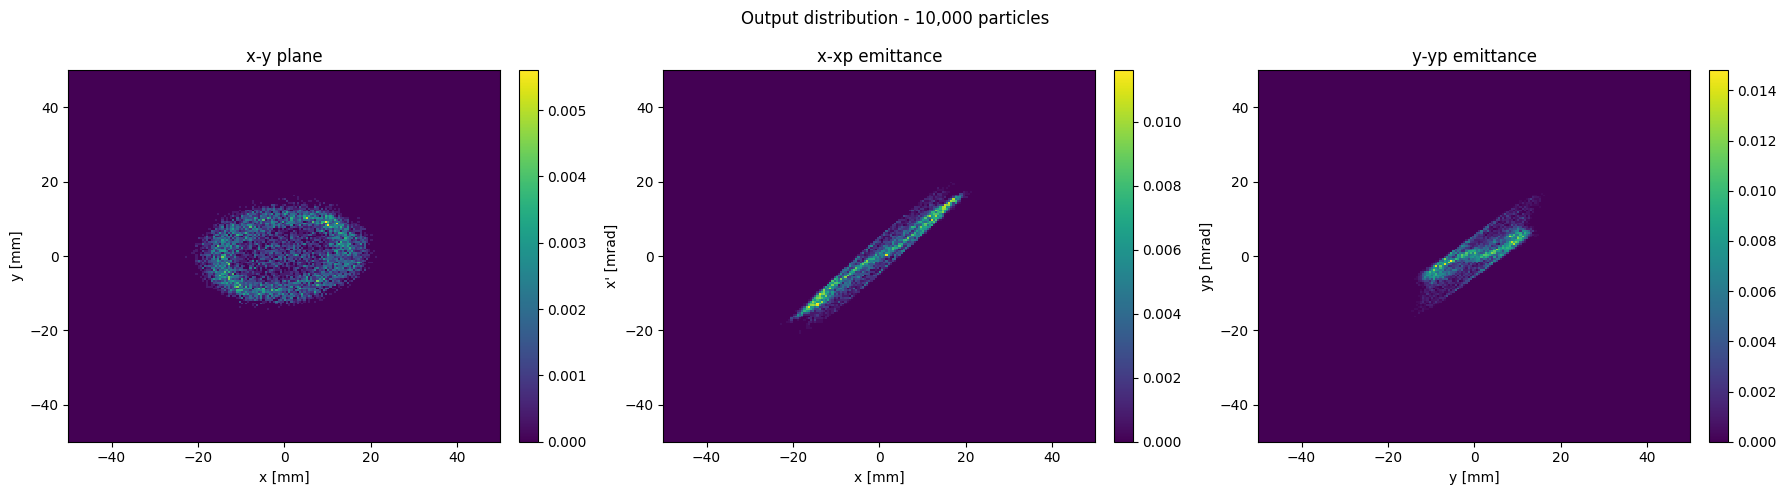

In [29]:
# Draw one figure for each distribution.
# Input/output use readable endpoint titles; intermediate snapshots use their calc filename.
for i, item in enumerate(distributions):
    if item['role'] == 'input':
        subtitle = f"{item['n_particles']:,} particles in reservoir, {NPART_SIMULATED:,} simulated"
    elif item['role'] == 'output':
        subtitle = f"{item['n_particles']:,} particles"
    else:
        subtitle = f"{item['n_particles']:,} particles"

    plot_tracewin_distribution(
        item['distribution'],
        title=f"{item['title']} - {subtitle}",
        figure_name=f"TraceWin distribution - {item['filename']}",
        bins=200,
        axis_range_mm=50.0,
        show=True,
    )


## Envelope plot

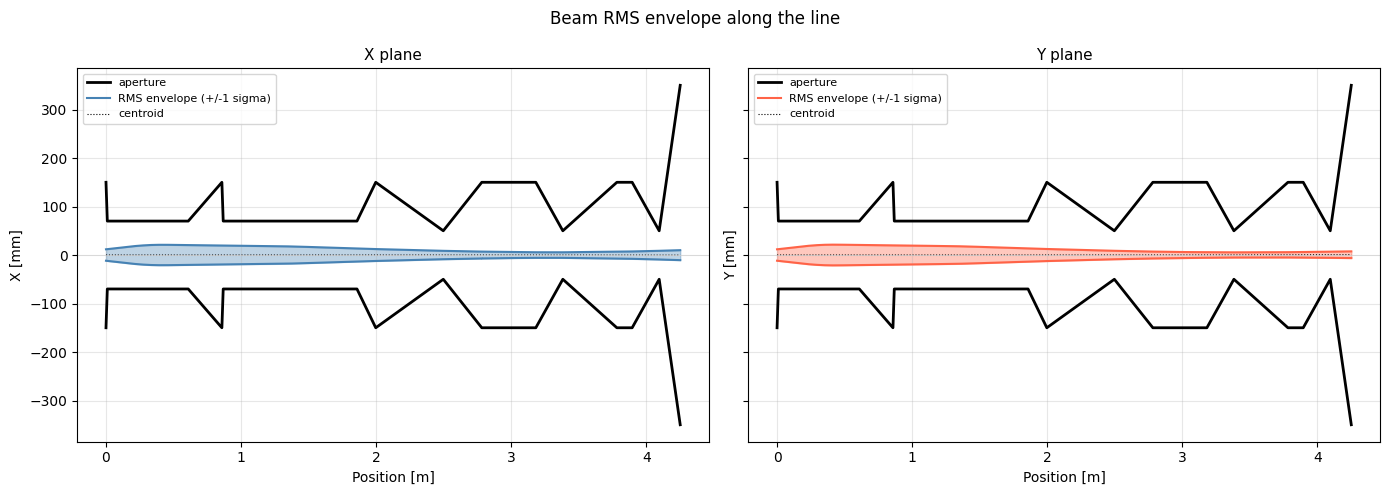

In [30]:
# Envelope plot from partran1.out.
# Black curves are aperture walls; colored bands show centroid +/- RMS size.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, plane, centroid_col, size_col, color in [
    (axes[0], 'X', 'x0', 'SizeX', 'steelblue'),
    (axes[1], 'Y', 'y0', 'SizeY', 'tomato'),
]:
    c0 = df[centroid_col]
    size = df[size_col]
    aper = df['Aper']

    ax.plot(z, aper, color='black', linewidth=2.0, label='aperture')
    ax.plot(z, -aper, color='black', linewidth=2.0)

    ax.fill_between(z, c0 - size, c0 + size, alpha=0.35, color=color)
    ax.plot(z, c0 + size, color=color, linewidth=1.5, label='RMS envelope (+/-1 sigma)')
    ax.plot(z, c0 - size, color=color, linewidth=1.5)
    ax.plot(z, c0, color='black', linewidth=0.8, linestyle=':', label='centroid')

    ax.axhline(0, color='lightgray', lw=0.5)
    ax.set_xlabel('Position [m]', fontsize=10)
    ax.set_ylabel(f'{plane} [mm]', fontsize=10)
    ax.set_title(f'{plane} plane', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Beam RMS envelope along the line', fontsize=12)
plt.tight_layout()
plt.show()